In [40]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [41]:
T = 15

## Question 1

The state transition matrix of the given system is the following.

In [42]:
A = np.array([
    [1.2, 0.2], 
    [0.7, 1.2]
])

The initial state is the following interval set.

In [43]:
z_initial = np.array([
    [.2, .3], 
    [.2, .3]
])

## Question 2

Two methods are implemented to compute the set of states reached by the system.

### Method 1 (Interval Matrix Method)

In [44]:
Z = np.zeros((T + 1, 2, 2))

Z[0] = z_initial

In [45]:
for t in range(1, T + 1):
    for row in range(2):
        interval_1 = [min(A[row, 0] * Z[t - 1, 0]), max(A[row, 0] * Z[t - 1, 0])]
        interval_2 = [min(A[row, 1] * Z[t - 1, 1]), max(A[row, 1] * Z[t - 1, 1])]

        Z[t, row] = [
            min(interval_1) + min(interval_2),
            max(interval_1) + max(interval_2)
        ]


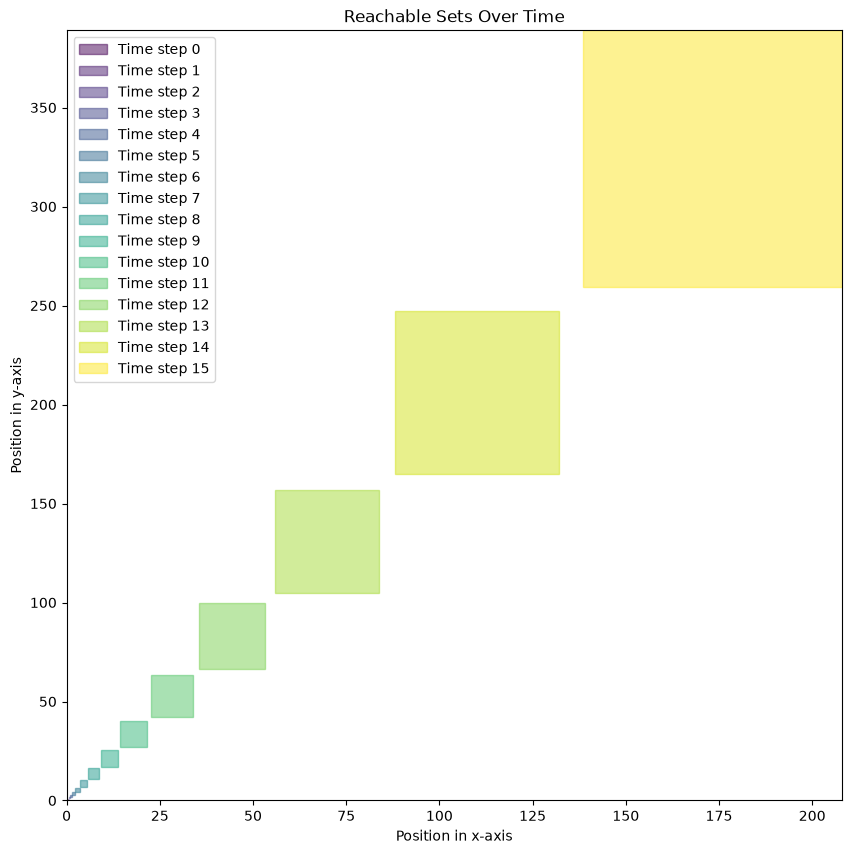

In [46]:
fig, ax = plt.subplots(figsize=(10, 10))

colors = plt.cm.viridis(np.linspace(0, 1, T + 1))

for t in range(T + 1):
    lower_left = [Z[t, 0, 0], Z[t, 1, 0]]
    upper_right = [Z[t, 0, 1], Z[t, 1, 1]]
    
    rect = patches.Rectangle((lower_left[0], lower_left[1]), upper_right[0] - lower_left[0], upper_right[1] - lower_left[1],
                             color=colors[t], alpha=0.5, label=f'Time step {t}') 

    ax.add_patch(rect)

ax.set_xlim(0, np.max(Z[:, 0,:]))
ax.set_ylim(0, np.max(Z[:, 1,:]))
ax.set_title('Reachable Sets Over Time')
ax.set_xlabel('Position in x-axis')
ax.set_ylabel('Position in y-axis')
ax.legend()
plt.show() 

### Method 2 (Vertex Shooting Method)

In [47]:
Z_vertices = np.zeros((T + 1, 4, 2))

Z_vertices[0] = np.array([
    [z_initial[0, 0], z_initial[1, 0]],  # Lower left
    [z_initial[0, 1], z_initial[1, 0]],  # Lower right
    [z_initial[0, 1], z_initial[1, 1]],  # Upper right
    [z_initial[0, 0], z_initial[1, 1]]   # Upper left
])

print("Z_vertices[0]:", Z_vertices[0])

Z_vertices[0]: [[0.2 0.2]
 [0.3 0.2]
 [0.3 0.3]
 [0.2 0.3]]


In [48]:
A @ Z_vertices[0][1]

for t in range(1, T + 1):
    for v in range(4):
        Z_vertices[t, v] = A @ Z_vertices[t - 1, v]


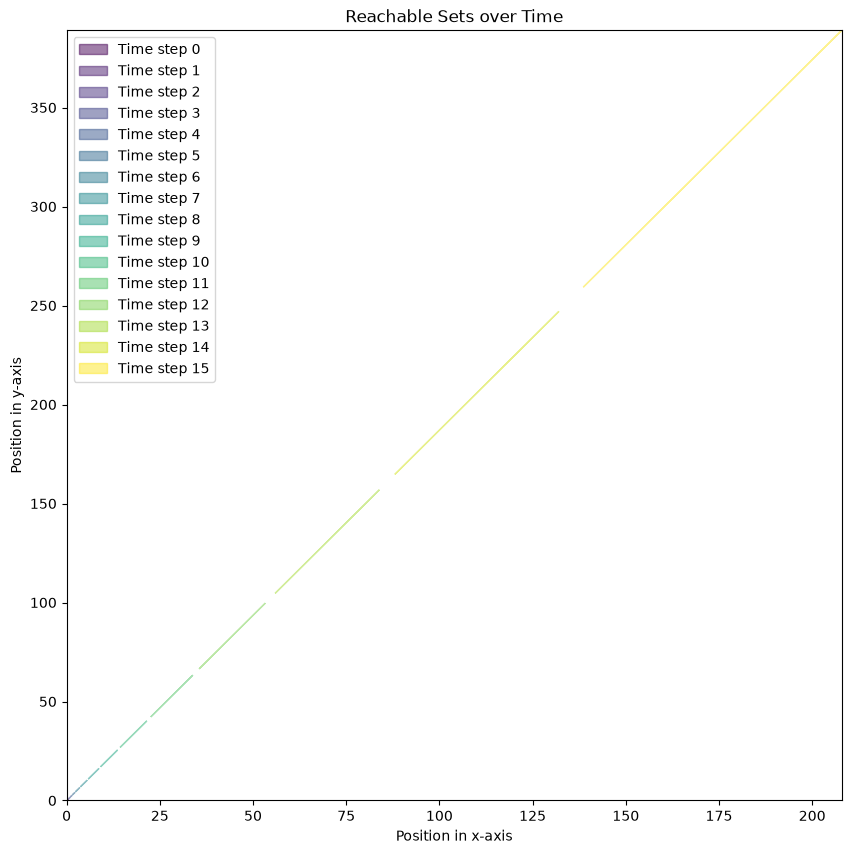

In [49]:
fig2, ax2 = plt.subplots(figsize=(10, 10))

for t in range(T + 1):
    polygon = patches.Polygon(Z_vertices[t], closed=True, color=colors[t], alpha=0.5, label=f'Time step {t}')
    ax2.add_patch(polygon)


ax2.set_xlim(0, np.max(Z_vertices[:, :, 0]))
ax2.set_ylim(0, np.max(Z_vertices[:, :, 1]))
ax2.set_title('Reachable Sets over Time')
ax2.set_xlabel('Position in x-axis')
ax2.set_ylabel('Position in y-axis')
ax2.legend()
plt.show() 

## Question 3

Five random initial points are selected from within the initial set, and their trajectories are plotted alongside the reachable sets computed using the vertex shooting method. The points are shown in different colors, with each point retaining the same color across all time steps. The points are not connected by lines to improve the clarity of the plot.

In [50]:
np.random.seed(42)

points = np.zeros((T+ 1, 5, 2))

for i in range(5):
    points[0, i, 0] = np.random.uniform(z_initial[0, 0], z_initial[0, 1])
    points[0, i, 1] = np.random.uniform(z_initial[1, 0], z_initial[1, 1])

for t in range(1, T + 1):
    for i in range(5):
        points[t, i] = A @ points[t - 1, i]


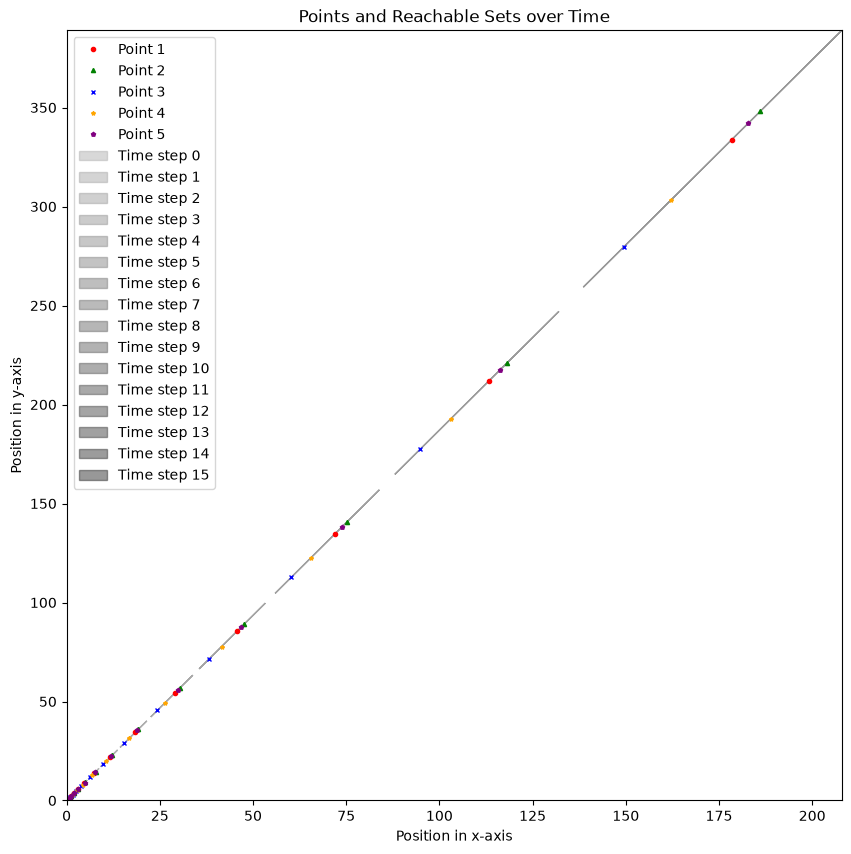

In [51]:
fig3, ax3 = plt.subplots(figsize=(10, 10))

colors_points = ['Red', 'Green', 'Blue', 'Orange', 'Purple']
markers = ['o', '^', 'x', '*', 'p']

for i in range(5):
    ax3.plot(
        points[:, i, 0],
        points[:, i, 1],
        color=colors_points[i],
        marker=markers[i],
        markersize=3,
        linestyle='None',
        label=f'Point {i + 1}'
    )

colors_reachable_sets = plt.cm.gray(np.linspace(0.7, 0.2, T + 1))
for t in range(T+1):
    polygon = patches.Polygon(Z_vertices[t], closed=True, color=colors_reachable_sets[t], alpha=0.5, label=f'Time step {t}')
    ax3.add_patch(polygon)

ax3.set_xlim(0, np.max(Z_vertices[:, :, 0]))
ax3.set_ylim(0, np.max(Z_vertices[:, :, 1]))
ax3.set_title('Points and Reachable Sets over Time')
ax3.set_xlabel('Position in x-axis')
ax3.set_ylabel('Position in y-axis')
ax3.legend()
plt.show()
